# Ablation Study: Anatomically-Constrained LDM vs Standard DDPM
This paper explores the impact of spatial conditioning (segmentation masks) on the generation of dental radiographs.
There are two objectives:
- **Qualitative comparison**: To demonstrate the anatomical collapse of the unconditioned DDPM compared to the guided LDM.
- **Constraint vs. Diversity trade-off**: To demonstrate that, given the same anatomical constraint (identical mask), the LDM is capable of generating diversity in texture and background (measured by varying the seed and validated using a segmenter).

In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import torchvision.transforms as T
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Execution on: {device}")

os.makedirs("ablation_plots", exist_ok=True)

Esecuzione su: cpu


## Comparison with the unconditioned DDPM
We load a patch generated by our first experiment (pure DDPM in pixel space) and compare it with a patch generated by our final model (conditioned LDM with VAE).

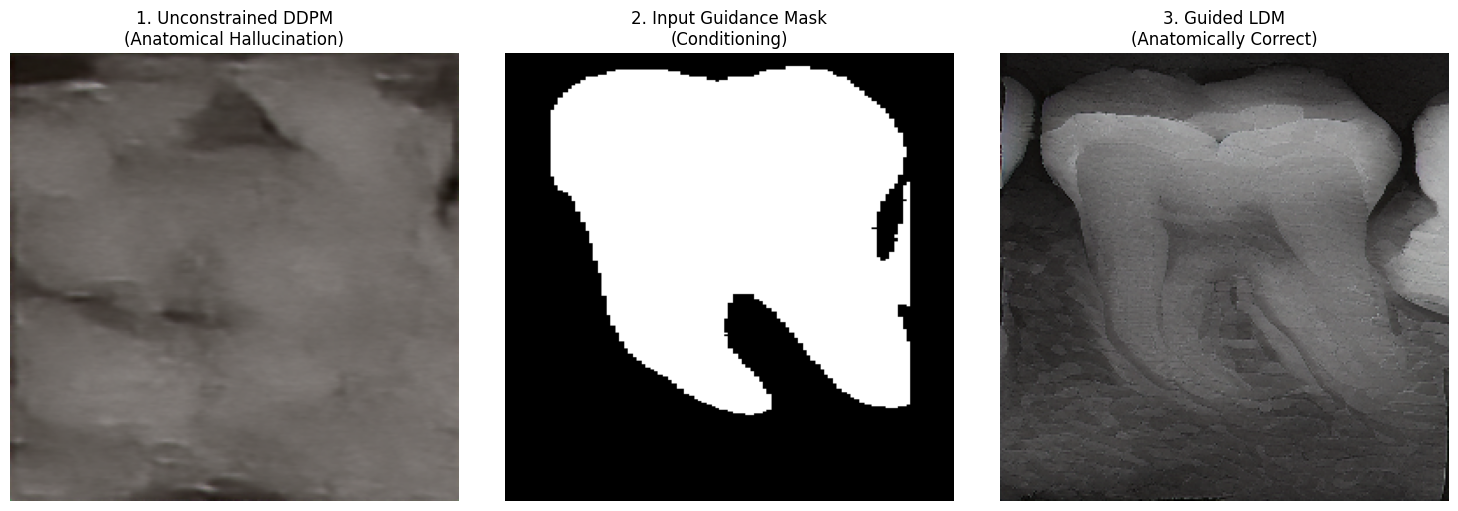

In [13]:
ddpm_image_path = "/content/drive/MyDrive/Colab Notebooks/cv-project3-anatomical-ldm/ddpm_baseline/ddpm_samples/ddpm_hallucination_1.png"
ldm_image_path = "/content/drive/MyDrive/Colab Notebooks/cv-project3-anatomical-ldm/outputs/generated_samples/synthetic_003_Image182_tooth_1_rbl_0.464.png"
mask_image_path = "/content/drive/MyDrive/Colab Notebooks/cv-project3-anatomical-ldm/processed_patches_severe_guided/train/masks/Image182_tooth_1_rbl_0.464.png"

try:
    img_ddpm = Image.open(ddpm_image_path).resize((256, 256))
    img_ldm = Image.open(ldm_image_path).resize((256, 256))
    img_mask = Image.open(mask_image_path).resize((256, 256))

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_ddpm)
    axes[0].set_title("1. Unconstrained DDPM\n(Anatomical Hallucination)")
    axes[0].axis("off")

    axes[1].imshow(img_mask, cmap='gray')
    axes[1].set_title("2. Input Guidance Mask\n(Conditioning)")
    axes[1].axis("off")

    axes[2].imshow(img_ldm, cmap='gray')
    axes[2].set_title("3. Guided LDM\n(Anatomically Correct)")
    axes[2].axis("off")

    plt.tight_layout()
    plt.savefig("ablation_plots/ddpm_vs_ldm.png", dpi=300)
    plt.show()
except FileNotFoundError:
    print("Enter the correct image paths to display the plot.")

## Mask Constraint vs. Generation Diversity
To demonstrate the trade-off, we fix **a single mask** (a strong constraint) and vary the initial noise (the latent seed) five times.
The expectation is that the network will consistently generate the tooth with the exact same shape and bone loss, while altering the background noise, trabecular bone, and overall contrast.

Exexution on: cpu
Loading VAE and U-Net...


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Preparation for spatial conditioning...
Generation of 5 anatomical variants with different seeds...
--> Variation with seed completed: 42
--> Variation with seed completed: 123
--> Variation with seed completed: 777
--> Variation with seed completed: 999
--> Variation with seed completed: 2026


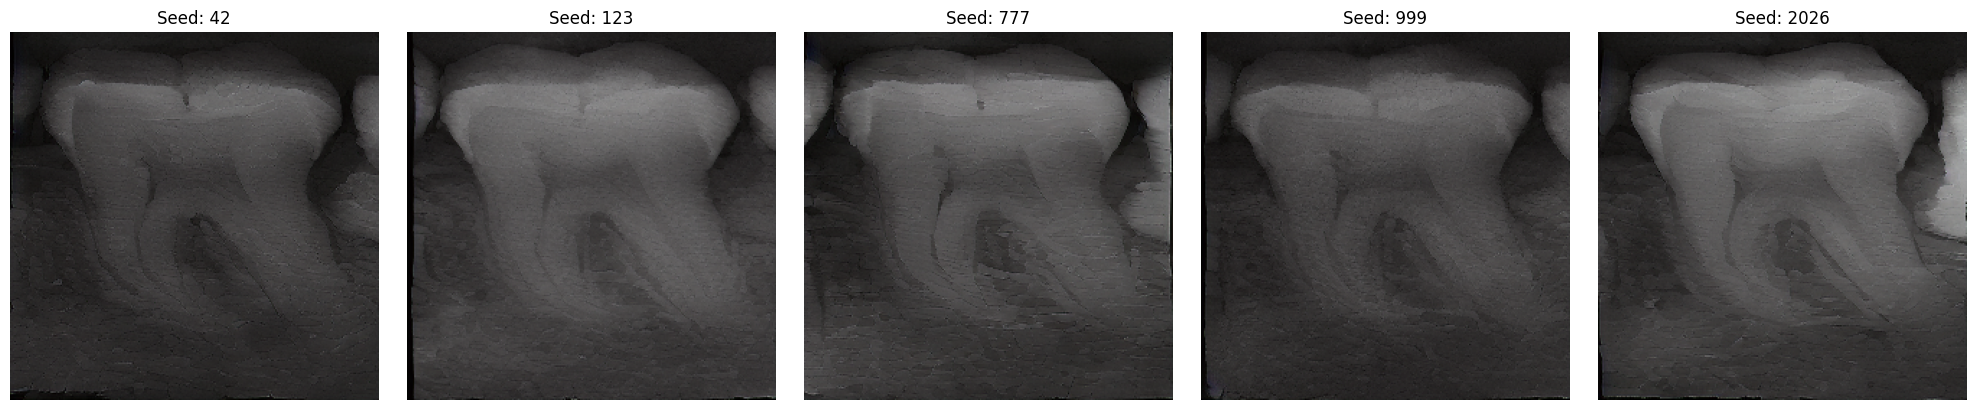

Plot successfully saved in ablation_plots/diversity_seeds.png


In [15]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from diffusers import AutoencoderKL, UNet2DConditionModel, DDPMScheduler
import os

checkpoint_path = "/content/drive/MyDrive/Colab Notebooks/cv-project3-anatomical-ldm/outputs/guided_ldm_checkpoint"
mask_path = "/content/drive/MyDrive/Colab Notebooks/cv-project3-anatomical-ldm/processed_patches_severe_guided/train/masks/Image182_tooth_1_rbl_0.464.png"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Exexution on: {device}")

print("Loading VAE and U-Net...")
vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(device)
unet = UNet2DConditionModel.from_pretrained(checkpoint_path).to(device)
vae.eval()
unet.eval()

scheduler = DDPMScheduler(num_train_timesteps=1000)
scheduler.set_timesteps(50)

# mask preparation and conditioning variables
print("Preparation for spatial conditioning...")
mask_img = Image.open(mask_path).convert("L")
transform_mask = T.Compose([T.ToTensor()])
mask_tensor = transform_mask(mask_img).unsqueeze(0).to(device)

mask_32 = F.interpolate(mask_tensor, size=(32, 32), mode="nearest")
dummy_encoder_hidden_states = torch.zeros((1, 1, 768), device=device) # bypass of text encoder


seeds = [42, 123, 777, 999, 2026]
generated_variations = []

print("Generation of 5 anatomical variants with different seeds...")
for seed in seeds:
    torch.manual_seed(seed)

    # initialize noise
    latents = torch.randn((1, 4, 32, 32), device=device)

    with torch.no_grad():
        for t in scheduler.timesteps:
            # Concatenate latents and mask along the channel dimension.
            unet_input = torch.cat([latents, mask_32], dim=1)
            noise_pred = unet(unet_input, t, encoder_hidden_states=dummy_encoder_hidden_states).sample
            latents = scheduler.step(noise_pred, t, latents).prev_sample

        # latent space -> pixel space decode
        decoded = vae.decode(latents / 0.18215).sample
        decoded = (decoded / 2 + 0.5).clamp(0, 1)

    # conversion in visible image
    final_img = T.ToPILImage()(decoded.squeeze(0).cpu())
    generated_variations.append(final_img)
    print(f"--> Variation with seed completed: {seed}")

# final plot
os.makedirs("ablation_plots", exist_ok=True)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for i, (img, s) in enumerate(zip(generated_variations, seeds)):
     axes[i].imshow(img, cmap='gray')
     axes[i].set_title(f"Seed: {s}")
     axes[i].axis("off")

plt.tight_layout()
plt.savefig("ablation_plots/diversity_seeds.png", dpi=300)
plt.show()
print("Plot successfully saved in ablation_plots/diversity_seeds.png")

## Ablation Study Conclusions

The qualitative tests performed in this notebook demonstrate two fundamental results for the validation of the pipeline:

- **Resolution of Hallucinations:** An unconditional pixel-space DDPM fails to reconstruct complex clinical topologies. Introducing a spatial mask into the LDM forces the model to adhere to anatomical boundaries, ensuring the clinical validity of the generated tooth and bone defect.
- **Constraint/Diversity Trade-off:** Multi-seed generation using the same mask confirms that the LDM is not simply "copy-pasting" the conditioning input. While the macro-structure remains fixed and faithful to the constraint, the model generates realistic diversity in high-frequency textures (trabecular bone and background).